In [90]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [93]:
data = pd.read_excel('Dry_Bean_Dataset.xlsx')

In [94]:
count = data['Class'].value_counts()
count

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

In [95]:
X = data.drop(columns=['Class']).values
y_text = data['Class'].values

le = LabelEncoder()
y = le.fit_transform(y_text)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
X_tr = torch.FloatTensor(X_train_scaled)
y_tr = torch.LongTensor(y_train)
X_te = torch.FloatTensor(X_test_scaled)
y_te = torch.LongTensor(y_test)

In [97]:
batch_size = 256
train_dataset = torch.utils.data.TensorDataset(X_tr, y_tr)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

In [98]:
class NeuralNet(nn.Module):
    def __init__(self, input_size=16, hidden_size=64, num_classes=7):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = NeuralNet()

num_epochs = 50
learning_rate = 0.01

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [99]:
total_step = len(train_loader)
loss_history = []
for epoch in range(num_epochs):
    epoch_loss = 0
    for i, (features, labels) in enumerate(train_loader):

        outputs = model(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, avg_loss))

with torch.no_grad():
    pred = model(X_te).argmax(dim=1)
    acc = (pred == y_te).float().mean().item()

print('\nТестовая точность (accuracy): {:.4f}'.format(acc))

Epoch [1/50], Loss: 0.5780
Epoch [2/50], Loss: 0.2277
Epoch [3/50], Loss: 0.2161
Epoch [4/50], Loss: 0.2026
Epoch [5/50], Loss: 0.2019
Epoch [6/50], Loss: 0.1954
Epoch [7/50], Loss: 0.1964
Epoch [8/50], Loss: 0.1877
Epoch [9/50], Loss: 0.1843
Epoch [10/50], Loss: 0.1868
Epoch [11/50], Loss: 0.1847
Epoch [12/50], Loss: 0.1862
Epoch [13/50], Loss: 0.1835
Epoch [14/50], Loss: 0.1808
Epoch [15/50], Loss: 0.1812
Epoch [16/50], Loss: 0.1810
Epoch [17/50], Loss: 0.1793
Epoch [18/50], Loss: 0.1779
Epoch [19/50], Loss: 0.1767
Epoch [20/50], Loss: 0.1819
Epoch [21/50], Loss: 0.1785
Epoch [22/50], Loss: 0.1764
Epoch [23/50], Loss: 0.1734
Epoch [24/50], Loss: 0.1705
Epoch [25/50], Loss: 0.1725
Epoch [26/50], Loss: 0.1747
Epoch [27/50], Loss: 0.1740
Epoch [28/50], Loss: 0.1706
Epoch [29/50], Loss: 0.1731
Epoch [30/50], Loss: 0.1799
Epoch [31/50], Loss: 0.1743
Epoch [32/50], Loss: 0.1693
Epoch [33/50], Loss: 0.1689
Epoch [34/50], Loss: 0.1694
Epoch [35/50], Loss: 0.1683
Epoch [36/50], Loss: 0.1670
E

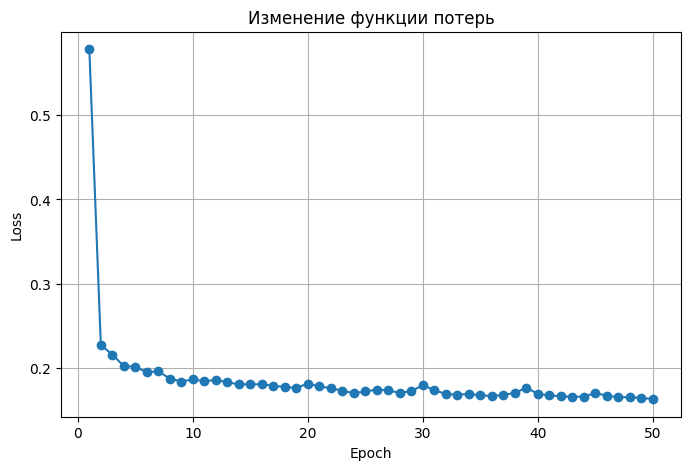

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), loss_history, marker='o')
plt.title('Изменение функции потерь')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Регрессия

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [102]:
data2 = pd.read_excel('Concrete_Data.xls')

In [103]:
data2.info()
data2 = data2.rename(columns={'Concrete compressive strength(MPa, megapascals) ': 'strength'})

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)        1030 

In [104]:
X = data2.drop(columns=['strength']).values
y = data2['strength'].values

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

In [105]:
X_tr = torch.FloatTensor(X_train_scaled)
y_tr = torch.FloatTensor(y_train).reshape(-1, 1)
X_te = torch.FloatTensor(X_test_scaled)
y_te = torch.FloatTensor(y_test)

In [106]:
batch_size = 128
train_dataset = torch.utils.data.TensorDataset(X_tr, y_tr)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

In [107]:
class NeuralNet2(nn.Module):
    def __init__(self, input_size=8, hidden_size=32, num_classes=1):
        super(NeuralNet2, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = NeuralNet2()

num_epochs = 500
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [108]:
total_step = len(train_loader)
loss_history = []
for epoch in range(num_epochs):
    epoch_loss = 0
    for i, (features, labels) in enumerate(train_loader):

        outputs = model(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, avg_loss))

model.eval()
with torch.no_grad():
    pred_scaled = model(X_te)

    pred_numpy = pred_scaled.numpy().reshape(-1, 1)
    y_te_numpy = y_te.numpy().reshape(-1, 1)

    pred_original = scaler_y.inverse_transform(pred_numpy)
    y_test_original = scaler_y.inverse_transform(y_te_numpy)

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    mae = mean_absolute_error(y_test_original, pred_original)
    mse = mean_squared_error(y_test_original, pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original, pred_original)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Epoch [1/500], Loss: 0.8333
Epoch [2/500], Loss: 0.4786
Epoch [3/500], Loss: 0.4324
Epoch [4/500], Loss: 0.3623
Epoch [5/500], Loss: 0.3203
Epoch [6/500], Loss: 0.2858
Epoch [7/500], Loss: 0.2564
Epoch [8/500], Loss: 0.2278
Epoch [9/500], Loss: 0.2135
Epoch [10/500], Loss: 0.1884
Epoch [11/500], Loss: 0.1760
Epoch [12/500], Loss: 0.1652
Epoch [13/500], Loss: 0.1546
Epoch [14/500], Loss: 0.1459
Epoch [15/500], Loss: 0.1409
Epoch [16/500], Loss: 0.1419
Epoch [17/500], Loss: 0.1311
Epoch [18/500], Loss: 0.1341
Epoch [19/500], Loss: 0.1281
Epoch [20/500], Loss: 0.1264
Epoch [21/500], Loss: 0.1210
Epoch [22/500], Loss: 0.1234
Epoch [23/500], Loss: 0.1153
Epoch [24/500], Loss: 0.1125
Epoch [25/500], Loss: 0.1124
Epoch [26/500], Loss: 0.1096
Epoch [27/500], Loss: 0.1094
Epoch [28/500], Loss: 0.1054
Epoch [29/500], Loss: 0.1051
Epoch [30/500], Loss: 0.1051
Epoch [31/500], Loss: 0.1072
Epoch [32/500], Loss: 0.1028
Epoch [33/500], Loss: 0.1042
Epoch [34/500], Loss: 0.1038
Epoch [35/500], Loss: 0

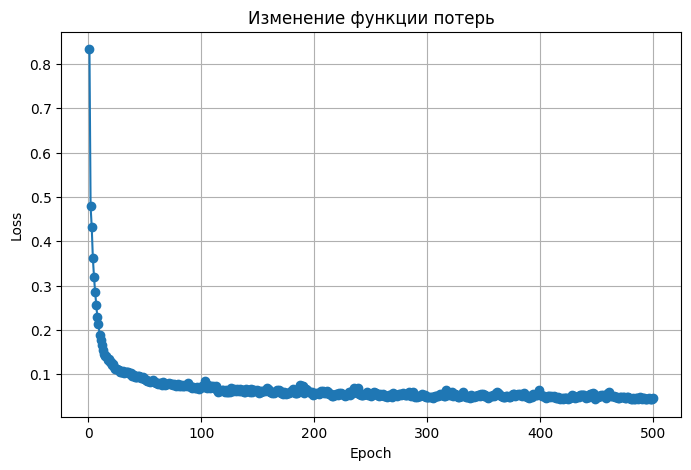

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), loss_history, marker='o')
plt.title('Изменение функции потерь')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()